In [1]:
import numpy as np
import matplotlib.pyplot as plt

from teaspoon.TDA.Draw import drawDgm
from teaspoon.TDA.BuZZ import PtClouds
from teaspoon.SP.tsa_tools import takens

In [2]:
t = np.linspace(0, 6*np.pi+1, 50)

# Amplitudes of sine waves
amps = [0.1,0.5,1,1.5,2,1.5,1,0.5,0.1]

ts_list = []
ptcloud_list = []
for a in amps:
    y = a*np.sin(t) + (0.1*np.random.randint(-100,100,len(t))/100)

    # Compute sine wave and add noise uniformly distributed in [-0.1, 0.1]
    ts_list.append(y)

    # Compute time delay embedding point clouds
    ptcloud_list.append(takens(y, n=2, tau=4))

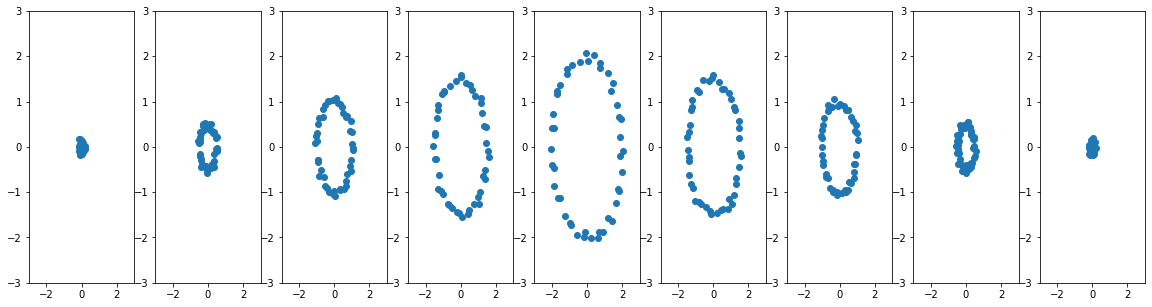

In [3]:
fig, ax = plt.subplots(1, len(ptcloud_list), figsize=(20, 5))
L = 3
for i in range(len(ptcloud_list)):
  plt.subplot(1,len(ptcloud_list),i+1)
  plt.scatter(ptcloud_list[i].T[0], ptcloud_list[i].T[1])
  plt.ylim([-L,L])
  plt.xlim([-L,L])

plt.show()

(25, 2)
(25, 2)
(25, 2)
(25, 2)
(25, 2)
(25, 2)
(25, 2)
(25, 2)
(25, 2)


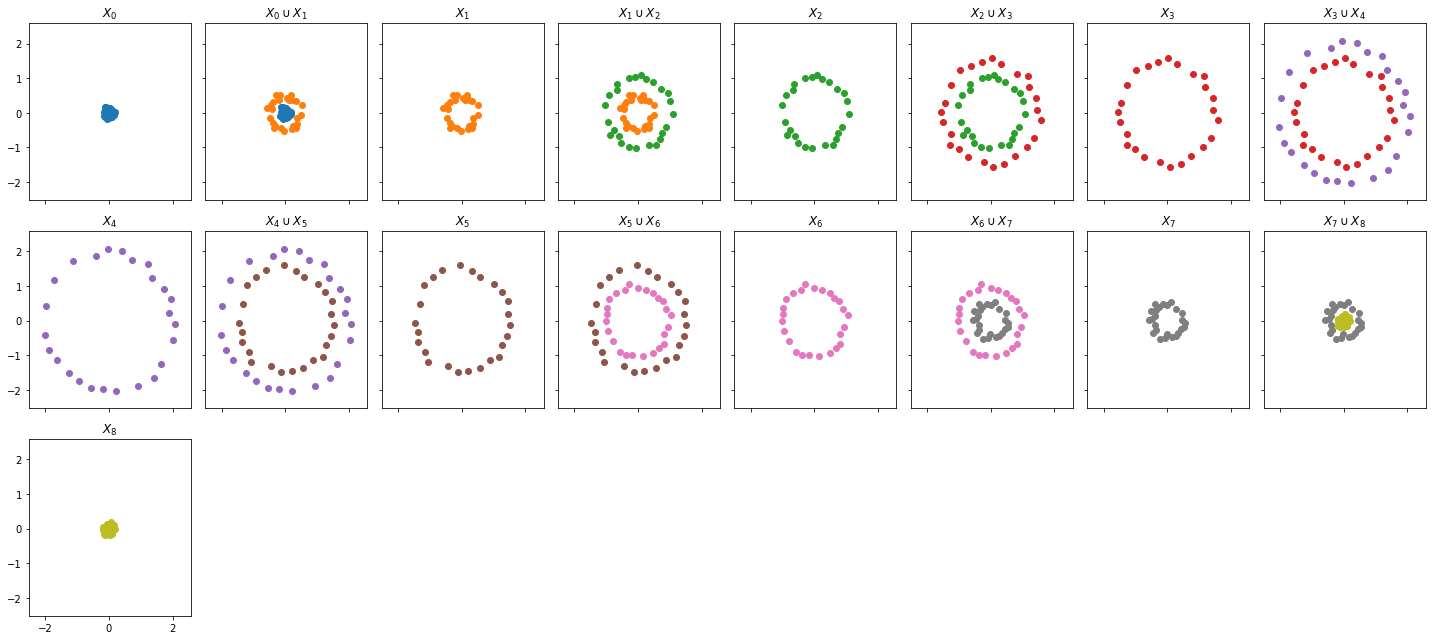

In [4]:
# Setup zigzag with point clouds
ZZ = PtClouds(ptcloud_list, num_landmarks=25, verbose=True)

# Plot zigzag of point clouds
ZZ.plot_ZZ_PtClouds()

Initializing done in 0.021098852157592773 seconds...
Preprocessing done in 23.296632051467896 seconds...
Time to build filtration, times:  23.361093997955322
Time to compute zigzag:  18.030739068984985
Total Time:  41.392005920410156 



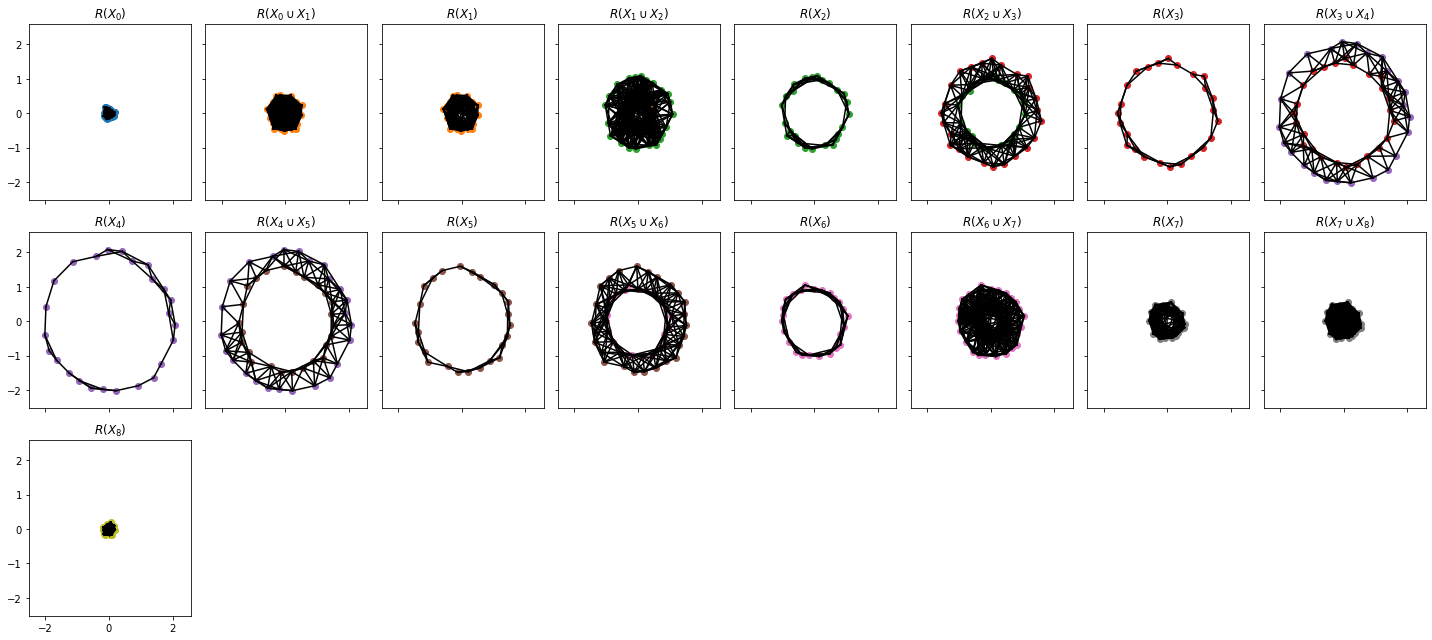

In [5]:
# Compute zigzag persistence
ZZ.run_Zigzag(r=0.9)

# Plot zigzag of Rips complexes
ZZ.plot_ZZ_Cplx()

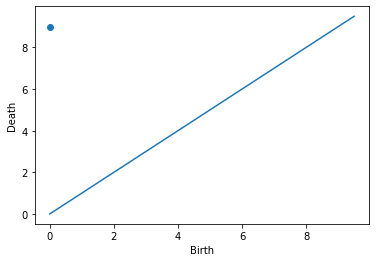

In [6]:
# Plot zigzag persistence diagram
drawDgm(ZZ.zz_dgms[0]) # 0-dimensional diagram
# drawDgm(ZZ.zz_dgms[1]) # 1-dimensional diagram

In [7]:
ptcloud_list[2].shape

(46, 2)